<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/ACTIVIDAD8_12_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CELDA 1: GENERACIÓN DE SEÑAL EN EL TIEMPO
Símbolos: [0. 1. 1. 0. 1. 0.]
Ts = 1.0 s (período de símbolo)
Δt = 0.004000 s (intervalo de muestreo)
fs = 250.00 Hz (frecuencia de muestreo)
Teorema de muestreo: Δt = 0.004000 ≤ 1/(2×5) = 0.100000 ✓
Muestras por símbolo: 250
Total de muestras: 1500
✓ Señal generada (suave, sin ruido y continua)



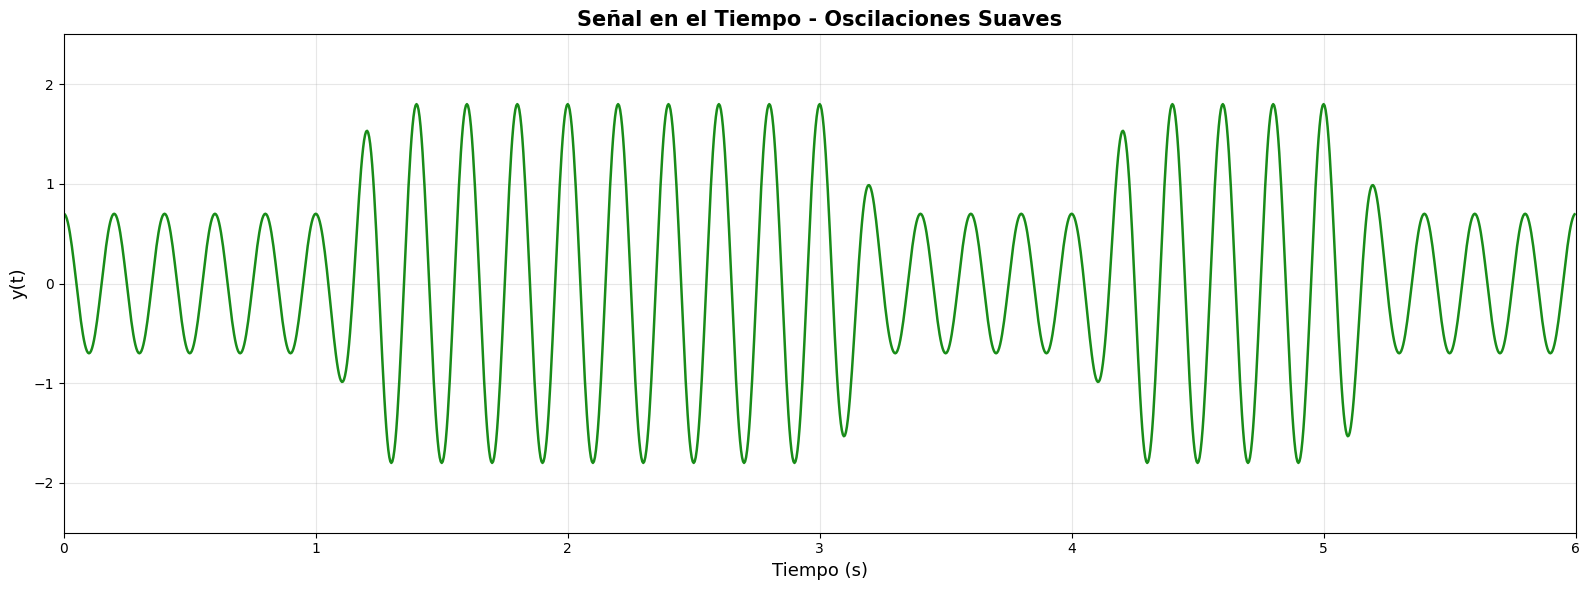

In [4]:
# ===============================================================
# CELDA 1: GENERAR SEÑAL EN EL TIEMPO (CONTINUA Y SUAVE)
# ===============================================================
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print("="*70)
print("CELDA 1: GENERACIÓN DE SEÑAL EN EL TIEMPO")
print("="*70)

# Parámetros
Ts = 1.0  # Período de símbolo (1 segundo por símbolo)
num_symbols = 6  # Número de símbolos
f_carrier = 5  # Frecuencia de la portadora (5 Hz) - para ver oscilaciones claras
f_max = f_carrier  # Frecuencia máxima de la señal

# Teorema de muestreo: Δt ≤ 1/(2*f_max)
delta_t = 1 / (50 * f_max)  # Sobremuestreo alto para señal suave
fs = 1 / delta_t  # Frecuencia de muestreo

# Símbolos a transmitir
symbols = torch.tensor([0, 1, 1, 0, 1, 0], dtype=torch.float32)
print(f"Símbolos: {symbols.numpy()}")

# Amplitudes (diferentes para cada símbolo)
a0 = 0.7   # Amplitud más baja para símbolo 0
a1 = 1.8   # Amplitud más alta para símbolo 1

# Tiempo total
t_total = num_symbols * Ts
t = np.arange(0, t_total, delta_t)
samples_per_symbol = int(Ts / delta_t)

print(f"Ts = {Ts} s (período de símbolo)")
print(f"Δt = {delta_t:.6f} s (intervalo de muestreo)")
print(f"fs = {fs:.2f} Hz (frecuencia de muestreo)")
print(f"Teorema de muestreo: Δt = {delta_t:.6f} ≤ 1/(2×{f_max}) = {1/(2*f_max):.6f} ✓")
print(f"Muestras por símbolo: {samples_per_symbol}")

# Generar señal SUAVE (sinusoidal pura modulada en amplitud)
# CON TRANSICIONES MUY SUAVES entre símbolos (SIN QUIEBRES)
signal_clean = np.zeros_like(t)

# Longitud de la zona de transición suave (30% del símbolo para máxima suavidad)
transition_samples = int(0.3 * samples_per_symbol)

for i, sym in enumerate(symbols):
    start_idx = i * samples_per_symbol
    end_idx = min((i + 1) * samples_per_symbol, len(t))
    t_segment = t[start_idx:end_idx]

    # Amplitud según el símbolo
    amplitude = a0 if sym == 0 else a1

    # Generar señal sinusoidal
    signal_segment = amplitude * np.cos(2 * np.pi * f_carrier * t_segment)

    # Aplicar transición MUY suave al inicio (si no es el primer símbolo)
    if i > 0:
        # Amplitud del símbolo anterior
        prev_amplitude = a0 if symbols[i-1] == 0 else a1

        # Crear rampa de transición SUAVE con función coseno (más suave que lineal)
        for j in range(min(transition_samples, len(signal_segment))):
            # Factor de interpolación suave (0 a 1) usando coseno
            alpha = 0.5 * (1 - np.cos(np.pi * j / transition_samples))

            # Interpolar entre amplitud anterior y nueva
            blended_amplitude = (1 - alpha) * prev_amplitude + alpha * amplitude
            signal_segment[j] = blended_amplitude * np.cos(2 * np.pi * f_carrier * t_segment[j])

    signal_clean[start_idx:end_idx] = signal_segment

# SIN RUIDO - señal limpia
signal_noisy = signal_clean.copy()  # Sin agregar ruido

# Convertir a PyTorch
y_t = torch.from_numpy(signal_noisy).float()
t_torch = torch.from_numpy(t).float()

print(f"Total de muestras: {len(y_t)}")
print("✓ Señal generada (suave, sin ruido y continua)\n")

# Graficar señal completa
plt.figure(figsize=(16, 6))
plt.plot(t, signal_noisy, linewidth=1.8, color='green', alpha=0.9)
plt.xlabel('Tiempo (s)', fontsize=13)
plt.ylabel('y(t)', fontsize=13)
plt.title('Señal en el Tiempo - Oscilaciones Suaves', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, t_total)
plt.ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

CELDA 2: IDENTIFICACIÓN DE SÍMBOLOS EN LA SEÑAL


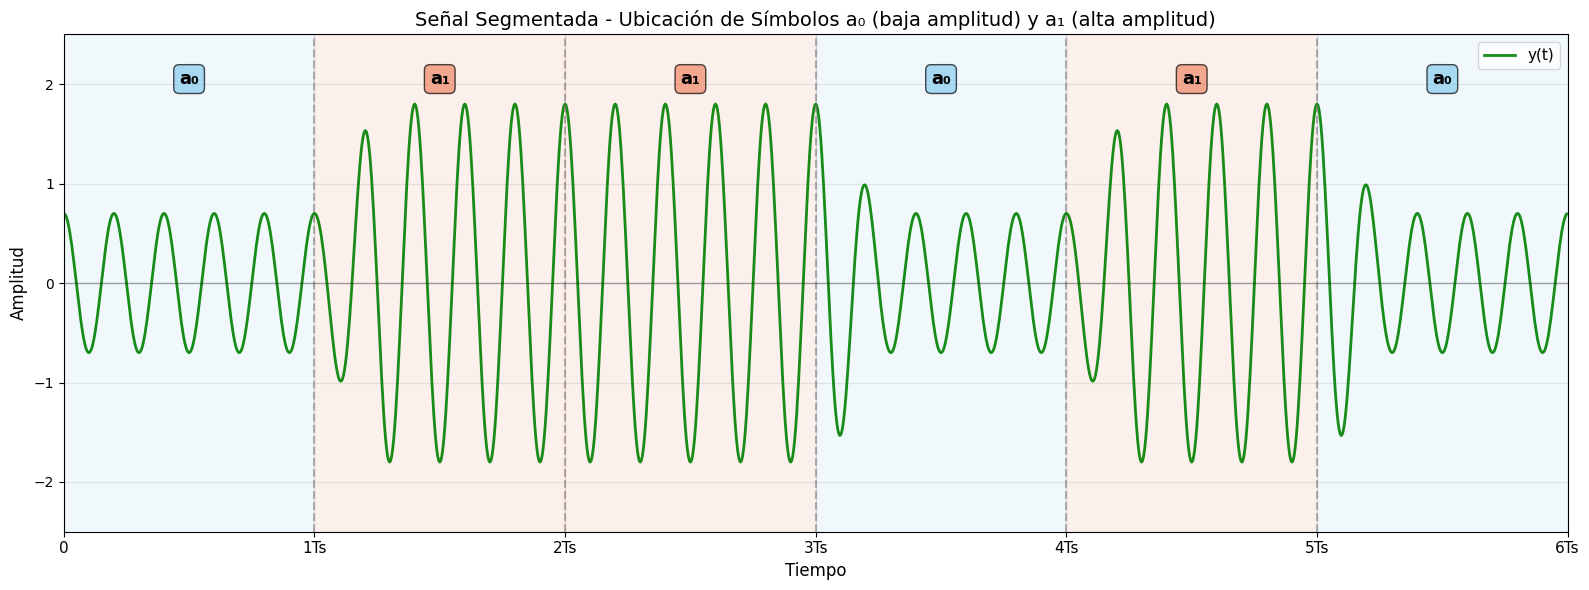

✓ Gráfica con símbolos identificados
   a₀ → amplitud baja  (0.7)
   a₁ → amplitud alta  (1.8)



In [5]:
# ===============================================================
# CELDA 2: GRAFICAR DÓNDE ESTÁN LOS SÍMBOLOS 0 Y 1
# ===============================================================
print("="*70)
print("CELDA 2: IDENTIFICACIÓN DE SÍMBOLOS EN LA SEÑAL")
print("="*70)

plt.figure(figsize=(16, 6))

# Graficar señal suave
plt.plot(t, signal_noisy, linewidth=2, color='green', alpha=0.9, label='y(t)')

# Marcar cada región de símbolo
for i, sym in enumerate(symbols):
    start_t = i * Ts
    end_t = (i + 1) * Ts
    mid_t = (start_t + end_t) / 2

    # Color según símbolo
    if sym == 0:
        color = '#88ccee'
        label_txt = 'a₀'
    else:
        color = '#ee8866'
        label_txt = 'a₁'

    # Sombrear región
    plt.axvspan(start_t, end_t, alpha=0.12, color=color)

    # Etiqueta arriba
    plt.text(mid_t, 2.0, label_txt, ha='center', fontsize=13, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

    # Línea divisoria entre símbolos
    if i > 0:
        plt.axvline(start_t, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)

# Eje x con marcas 0, Ts, 2Ts, 3Ts...
x_ticks = [k * Ts for k in range(num_symbols + 1)]
x_labels = ['0'] + [f'{k}Ts' for k in range(1, num_symbols + 1)]
plt.xticks(x_ticks, x_labels, fontsize=11)

plt.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Amplitud', fontsize=12)
plt.title('Señal Segmentada - Ubicación de Símbolos a₀ (baja amplitud) y a₁ (alta amplitud)',
          fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, t_total)
plt.ylim(-2.5, 2.5)
plt.tight_layout()
plt.show()

print("✓ Gráfica con símbolos identificados")
print(f"   a₀ → amplitud baja  ({a0})")
print(f"   a₁ → amplitud alta  ({a1})\n")

CELDA 3: DISCRETIZACIÓN - PALITOS EN LOMOS SUPERIOR E INFERIOR
Intervalo de muestreo: Δt = 0.004000 s
Frecuencia de muestreo: fs = 1/Δt = 250.00 Hz
Cumple teorema de Nyquist: Δt ≤ 1/(2×f_max)

✓ Envolventes calculadas



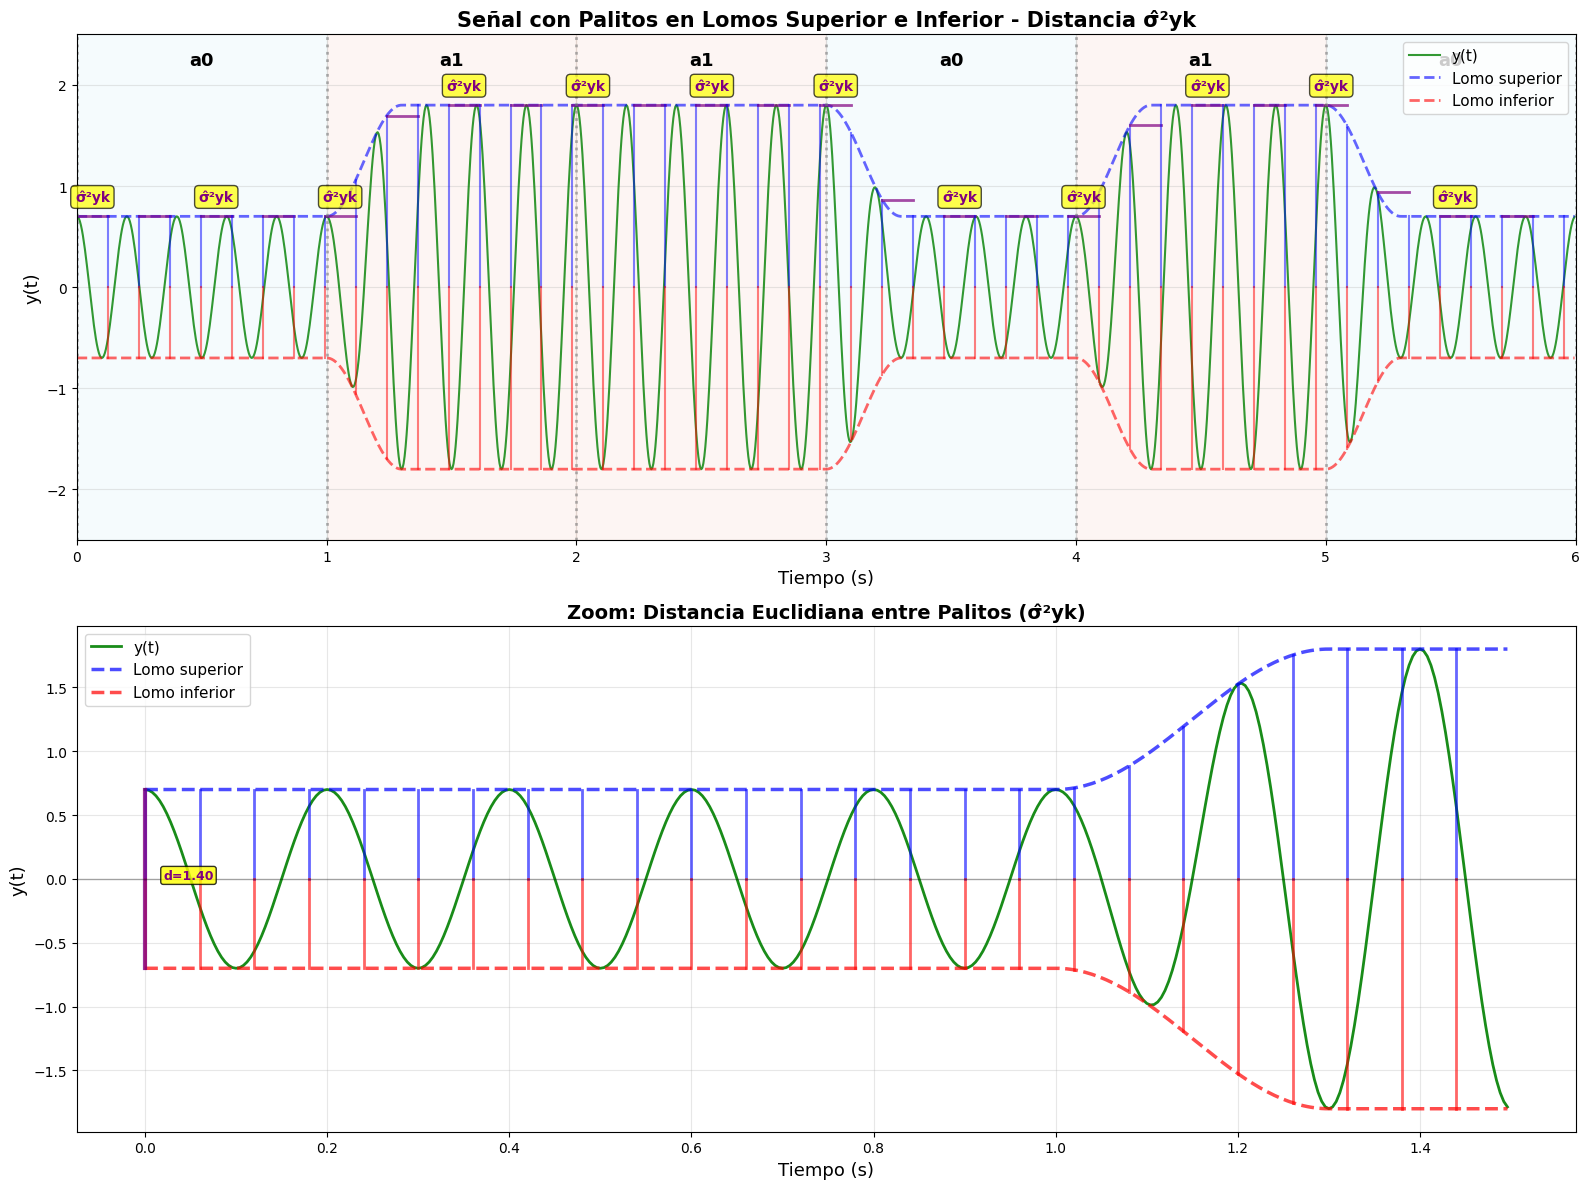


INTERPRETACIÓN:
  - Palitos azules: muestras en el lomo superior
  - Palitos rojos: muestras en el lomo inferior
  - σ̂²yk: distancia euclidiana entre muestras consecutivas
  - La distancia vertical entre palitos representa la dispersión de la señal


In [6]:
# ===============================================================
# CELDA 3: DISCRETIZACIÓN CON "PALITOS" Y ENVOLVENTES
# ===============================================================
print("="*70)
print("CELDA 3: DISCRETIZACIÓN - PALITOS EN LOMOS SUPERIOR E INFERIOR")
print("="*70)

# Calcular la envolvente (lomo superior e inferior) de la señal
# La envolvente es la amplitud de cada segmento
envelope_upper = np.zeros_like(t)
envelope_lower = np.zeros_like(t)

for i, sym in enumerate(symbols):
    start_idx = i * samples_per_symbol
    end_idx = min((i + 1) * samples_per_symbol, len(t))

    amplitude = a0 if sym == 0 else a1

    # Aplicar transición suave también a la envolvente
    if i > 0:
        prev_amplitude = a0 if symbols[i-1] == 0 else a1
        for j in range(min(transition_samples, end_idx - start_idx)):
            alpha = 0.5 * (1 - np.cos(np.pi * j / transition_samples))
            blended_amplitude = (1 - alpha) * prev_amplitude + alpha * amplitude
            envelope_upper[start_idx + j] = blended_amplitude
            envelope_lower[start_idx + j] = -blended_amplitude

        # Resto del segmento con amplitud constante
        envelope_upper[start_idx + transition_samples:end_idx] = amplitude
        envelope_lower[start_idx + transition_samples:end_idx] = -amplitude
    else:
        envelope_upper[start_idx:end_idx] = amplitude
        envelope_lower[start_idx:end_idx] = -amplitude

print(f"Intervalo de muestreo: Δt = {delta_t:.6f} s")
print(f"Frecuencia de muestreo: fs = 1/Δt = {1/delta_t:.2f} Hz")
print(f"Cumple teorema de Nyquist: Δt ≤ 1/(2×f_max)")
print("\n✓ Envolventes calculadas\n")

# VISUALIZACIÓN - Señal con palitos en los lomos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# ========== PANEL 1: Señal completa con envolventes y palitos ==========
ax1.plot(t, signal_noisy, linewidth=1.5, color='green', alpha=0.8, label='y(t)')

# Dibujar envolventes (lomos superior e inferior)
ax1.plot(t, envelope_upper, 'b--', linewidth=2, alpha=0.6, label='Lomo superior')
ax1.plot(t, envelope_lower, 'r--', linewidth=2, alpha=0.6, label='Lomo inferior')

# Dibujar "palitos" en los lomos cada cierto intervalo
palito_interval = samples_per_symbol // 8  # Un palito cada 8va parte del símbolo

for i in range(0, len(t), palito_interval):
    # Palito en lomo superior
    ax1.plot([t[i], t[i]], [0, envelope_upper[i]],
             'b-', linewidth=1.5, alpha=0.5)

    # Palito en lomo inferior
    ax1.plot([t[i], t[i]], [0, envelope_lower[i]],
             'r-', linewidth=1.5, alpha=0.5)

    # Línea horizontal mostrando la distancia entre palitos (σ̂²yk)
    if i % (palito_interval * 2) == 0 and i < len(t) - palito_interval:
        next_i = i + palito_interval
        if next_i < len(t):
            # Distancia en el lomo superior
            mid_y_upper = envelope_upper[i]
            ax1.plot([t[i], t[next_i]], [mid_y_upper, mid_y_upper],
                    'purple', linewidth=2, alpha=0.7)

            # Etiqueta σ̂²yk
            if i % (palito_interval * 4) == 0:
                ax1.text((t[i] + t[next_i])/2, mid_y_upper + 0.15,
                        'σ̂²yk', ha='center', fontsize=10,
                        color='purple', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Marcar divisiones de símbolos
for k in range(num_symbols + 1):
    ax1.axvline(k * Ts, color='gray', linestyle=':', alpha=0.6, linewidth=2)
    if k < num_symbols:
        color = '#88ccee' if symbols[k] == 0 else '#ee8866'
        ax1.axvspan(k * Ts, (k+1) * Ts, alpha=0.08, color=color)
        ax1.text(k*Ts + Ts/2, 2.2, f'a{symbols[k].item():.0f}',
                ha='center', fontsize=13, fontweight='bold')

ax1.set_xlabel('Tiempo (s)', fontsize=13)
ax1.set_ylabel('y(t)', fontsize=13)
ax1.set_title('Señal con Palitos en Lomos Superior e Inferior - Distancia σ̂²yk',
             fontsize=15, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, t_total)
ax1.set_ylim(-2.5, 2.5)

# ========== PANEL 2: Zoom en un segmento mostrando distancia euclidiana ==========
# Tomar primer símbolo para zoom
zoom_start = 0
zoom_end = int(1.5 * samples_per_symbol)
t_zoom = t[zoom_start:zoom_end]
signal_zoom = signal_noisy[zoom_start:zoom_end]
env_upper_zoom = envelope_upper[zoom_start:zoom_end]
env_lower_zoom = envelope_lower[zoom_start:zoom_end]

ax2.plot(t_zoom, signal_zoom, linewidth=2, color='green', alpha=0.9, label='y(t)')
ax2.plot(t_zoom, env_upper_zoom, 'b--', linewidth=2.5, alpha=0.7, label='Lomo superior')
ax2.plot(t_zoom, env_lower_zoom, 'r--', linewidth=2.5, alpha=0.7, label='Lomo inferior')

# Palitos en zoom con más detalle
for i in range(0, len(t_zoom), palito_interval//2):
    # Palito superior
    ax2.plot([t_zoom[i], t_zoom[i]], [0, env_upper_zoom[i]],
             'b-', linewidth=2, alpha=0.6)

    # Palito inferior
    ax2.plot([t_zoom[i], t_zoom[i]], [0, env_lower_zoom[i]],
             'r-', linewidth=2, alpha=0.6)

    # Mostrar algunas distancias
    if i % palito_interval == 0 and i + palito_interval//2 < len(t_zoom):
        next_i = i + palito_interval//2

        # Distancia vertical entre palitos (distancia euclidiana)
        y_upper = env_upper_zoom[i]
        y_lower = env_lower_zoom[i]

        # Línea vertical mostrando distancia
        ax2.plot([t_zoom[i], t_zoom[i]], [y_lower, y_upper],
                'purple', linewidth=3, alpha=0.8)

        # Calcular distancia euclidiana
        dist_euclidean = np.sqrt((y_upper - y_lower)**2)

        if i % (palito_interval * 2) == 0:
            ax2.text(t_zoom[i] + 0.02, 0, f'd={dist_euclidean:.2f}',
                    fontsize=9, color='purple', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.8))

ax2.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax2.set_xlabel('Tiempo (s)', fontsize=13)
ax2.set_ylabel('y(t)', fontsize=13)
ax2.set_title('Zoom: Distancia Euclidiana entre Palitos (σ̂²yk)',
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nINTERPRETACIÓN:")
print("  - Palitos azules: muestras en el lomo superior")
print("  - Palitos rojos: muestras en el lomo inferior")
print("  - σ̂²yk: distancia euclidiana entre muestras consecutivas")
print("  - La distancia vertical entre palitos representa la dispersión de la señal")

CELDA 4: EXTRACCIÓN DE CARACTERÍSTICAS (FEATURE)
Total de segmentos: 6
Muestras por segmento: 250

Segmento 0: ŝ_0 = +0.0000 (símbolo enviado: a0)
Segmento 1: ŝ_1 = -0.0022 (símbolo enviado: a1)
Segmento 2: ŝ_2 = +0.0000 (símbolo enviado: a1)
Segmento 3: ŝ_3 = +0.0022 (símbolo enviado: a0)
Segmento 4: ŝ_4 = -0.0022 (símbolo enviado: a1)
Segmento 5: ŝ_5 = +0.0022 (símbolo enviado: a0)

Características: [ 2.3841859e-10 -2.2000021e-03  0.0000000e+00  2.1999988e-03
 -2.2000021e-03  2.1999988e-03]
✓ Features extraídos



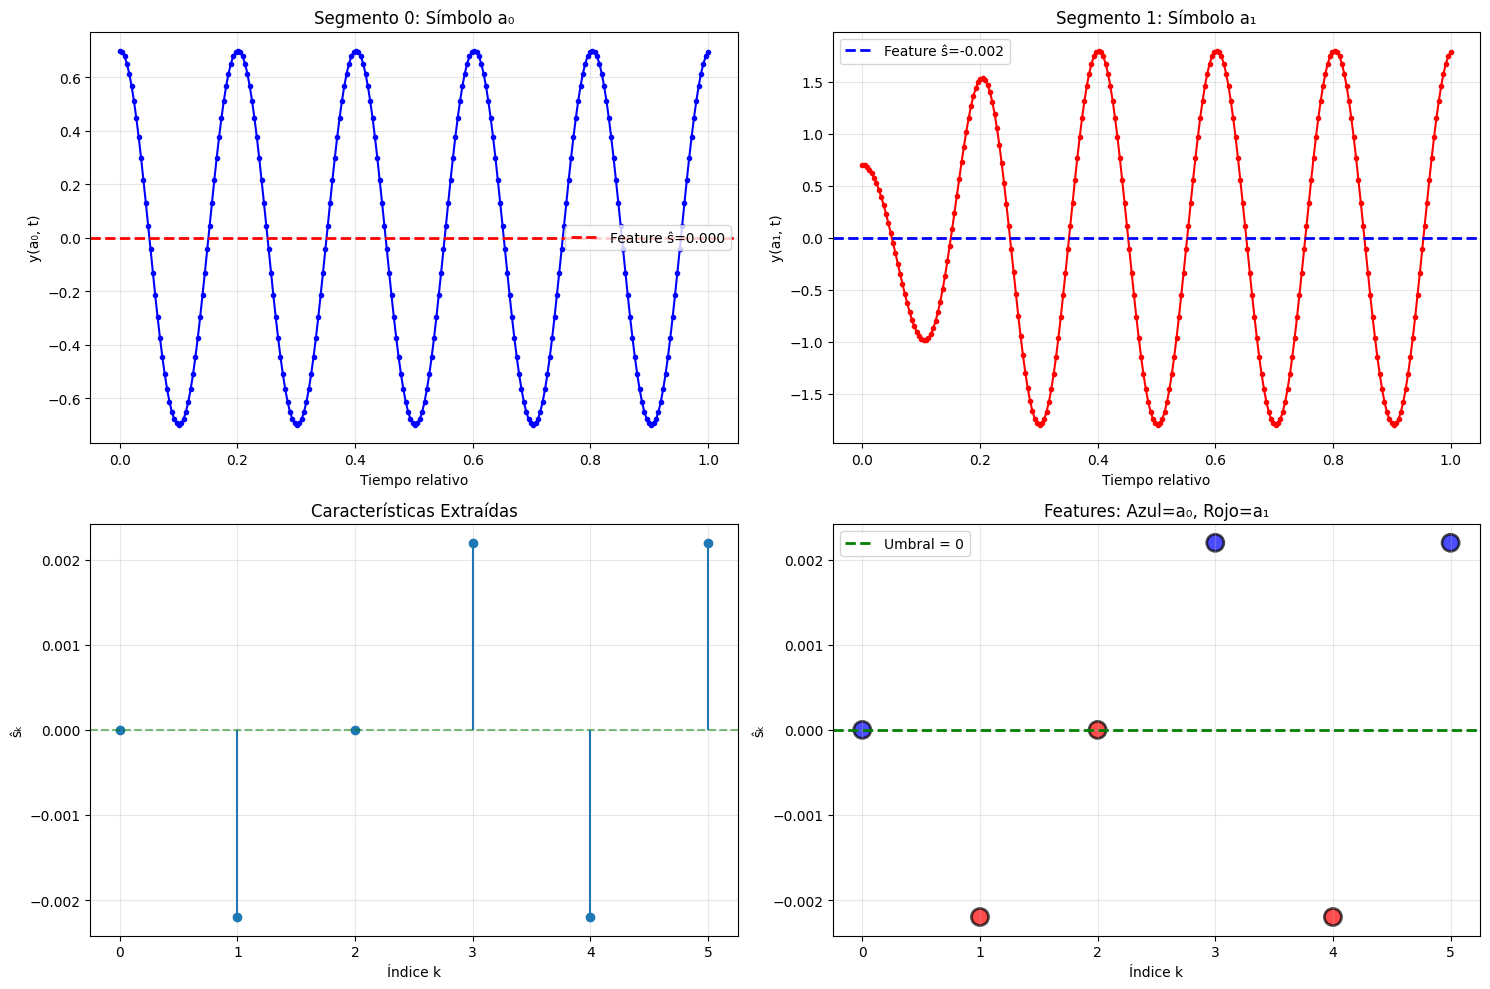

In [8]:
# ===============================================================
# CELDA 4: FEATURE EXTRACTION - ŝₖ = F{y(aᵢ,t): t∈[kTs, (k+1)Ts]}
# ===============================================================
print("="*70)
print("CELDA 4: EXTRACCIÓN DE CARACTERÍSTICAS (FEATURE)")
print("="*70)

# Segmentar la señal en bloques de duración Ts
# Cada segmento: y(aᵢ, t) donde t ∈ [kTs, (k+1)Ts]
segments_list = []

for k in range(num_symbols):
    start_idx = k * samples_per_symbol
    end_idx = min((k + 1) * samples_per_symbol, len(y_t))

    # Extraer segmento
    segment = y_t[start_idx:end_idx]
    segments_list.append(segment)

print(f"Total de segmentos: {len(segments_list)}")
print(f"Muestras por segmento: {len(segments_list[0])}\n")

# Feature: Característica extraída de cada segmento
# Usamos la MEDIA (valor promedio) como característica
s_hat = []

for k, segment in enumerate(segments_list):
    # ŝₖ = F{y(aᵢ,t)} = media del segmento
    feature = torch.mean(segment)
    s_hat.append(feature)
    print(f"Segmento {k}: ŝ_{k} = {feature.item():+.4f} (símbolo enviado: a{symbols[k].item():.0f})")

s_hat = torch.stack(s_hat)

print(f"\nCaracterísticas: {s_hat.numpy()}")
print("✓ Features extraídos\n")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Ejemplo de un segmento (símbolo 0)
k0 = torch.where(symbols == 0)[0][0].item()
t_seg0 = torch.linspace(0, Ts, len(segments_list[k0]))
axes[0, 0].plot(t_seg0.numpy(), segments_list[k0].numpy(),
                'o-', linewidth=1.5, markersize=3, color='blue')
axes[0, 0].axhline(s_hat[k0].item(), color='red', linestyle='--',
                   linewidth=2, label=f'Feature ŝ={s_hat[k0].item():.3f}')
axes[0, 0].set_xlabel('Tiempo relativo')
axes[0, 0].set_ylabel('y(a₀, t)')
axes[0, 0].set_title(f'Segmento {k0}: Símbolo a₀')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Ejemplo de un segmento (símbolo 1)
k1 = torch.where(symbols == 1)[0][0].item()
t_seg1 = torch.linspace(0, Ts, len(segments_list[k1]))
axes[0, 1].plot(t_seg1.numpy(), segments_list[k1].numpy(),
                'o-', linewidth=1.5, markersize=3, color='red')
axes[0, 1].axhline(s_hat[k1].item(), color='blue', linestyle='--',
                   linewidth=2, label=f'Feature ŝ={s_hat[k1].item():.3f}')
axes[0, 1].set_xlabel('Tiempo relativo')
axes[0, 1].set_ylabel('y(a₁, t)')
axes[0, 1].set_title(f'Segmento {k1}: Símbolo a₁')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Features de todos los símbolos
axes[1, 0].stem(range(num_symbols), s_hat.numpy(), basefmt=' ')
axes[1, 0].axhline(0, color='green', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Índice k')
axes[1, 0].set_ylabel('ŝₖ')
axes[1, 0].set_title('Características Extraídas')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Features separados por símbolo
colors = ['blue' if s == 0 else 'red' for s in symbols]
axes[1, 1].scatter(range(num_symbols), s_hat.numpy(),
                   c=colors, s=150, alpha=0.7, edgecolors='black', linewidths=2)
axes[1, 1].axhline(0, color='green', linestyle='--', linewidth=2, label='Umbral = 0')
axes[1, 1].set_xlabel('Índice k')
axes[1, 1].set_ylabel('ŝₖ')
axes[1, 1].set_title('Features: Azul=a₀, Rojo=a₁')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

CELDA 5: CÁLCULO DE σ̂²ᵧₖ (DISTANCIA EUCLIDIANA)
Segmento 0: σ²ᵧₖ = 0.245000, d²_eucl = 0.003879 (símbolo: a0)
Segmento 1: σ²ᵧₖ = 1.385558, d²_eucl = 0.022065 (símbolo: a1)
Segmento 2: σ²ᵧₖ = 1.620000, d²_eucl = 0.025650 (símbolo: a1)
Segmento 3: σ²ᵧₖ = 0.434058, d²_eucl = 0.006825 (símbolo: a0)
Segmento 4: σ²ᵧₖ = 1.385558, d²_eucl = 0.022065 (símbolo: a1)
Segmento 5: σ²ᵧₖ = 0.434058, d²_eucl = 0.006825 (símbolo: a0)

Varianzas σ²ᵧₖ: [0.245      1.3855577  1.62       0.43405765 1.3855577  0.43405765]
Distancias euclidianas: [0.00387919 0.02206483 0.02565016 0.00682535 0.02206483 0.00682535]

✓ σ̂²ᵧₖ calculado (representa dispersión y distancia entre muestras)



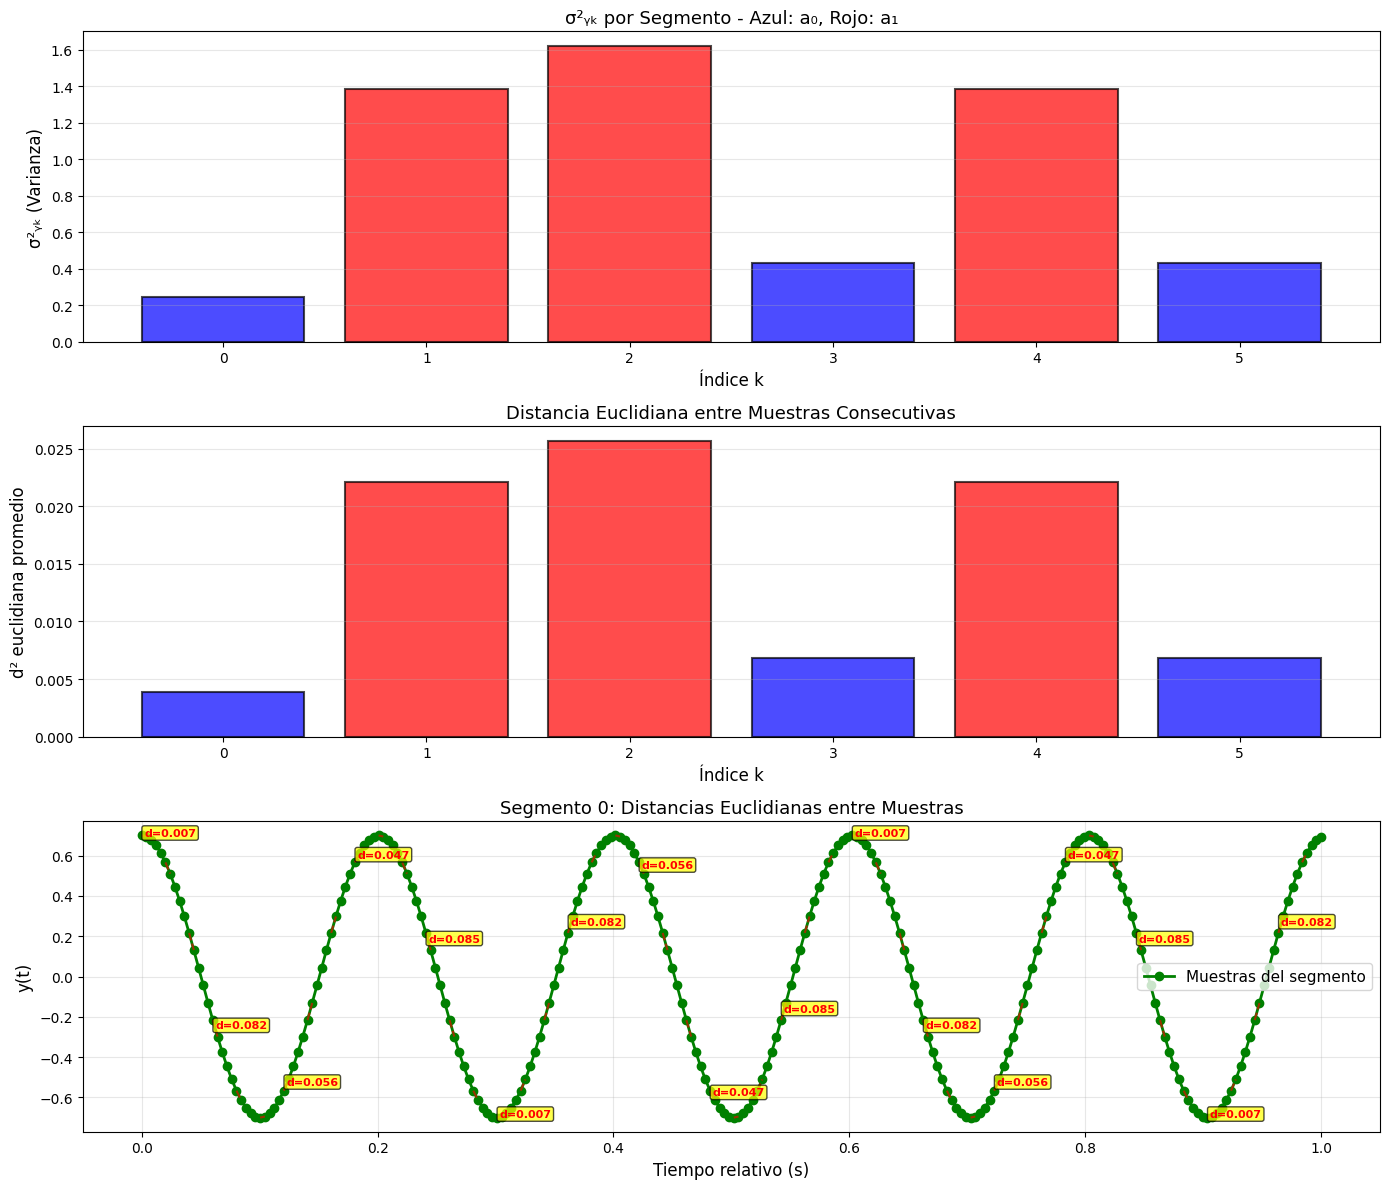


NOTA IMPORTANTE:
  σ̂²ᵧₖ = distancia euclidiana al cuadrado entre muestras
  Representa la 'dispersión' o 'variabilidad' dentro del segmento
  Como el profe dibujó: distancia entre palitos del lomo superior e inferior


In [9]:
# ===============================================================
# CELDA 5: σ̂²ᵧₖ - DISTANCIA EUCLIDIANA ENTRE MUESTRAS
# ===============================================================
print("="*70)
print("CELDA 5: CÁLCULO DE σ̂²ᵧₖ (DISTANCIA EUCLIDIANA)")
print("="*70)

# σ̂²ᵧₖ representa la distancia euclidiana entre muestras del segmento
# Se puede calcular como:
# 1. Varianza de las muestras: σ² = (1/N) Σ(yᵢ - ȳ)²
# 2. Distancia euclidiana promedio entre muestras consecutivas

sigma_squared_list = []
euclidean_distances = []

for k, segment in enumerate(segments_list):
    # Método 1: Varianza del segmento
    sigma_sq = torch.var(segment, unbiased=False)
    sigma_squared_list.append(sigma_sq)

    # Método 2: Distancia euclidiana promedio entre muestras consecutivas
    if len(segment) > 1:
        # Calcular diferencias entre muestras consecutivas
        diffs = segment[1:] - segment[:-1]
        # Distancia euclidiana promedio
        eucl_dist = torch.mean(diffs ** 2)
        euclidean_distances.append(eucl_dist)
    else:
        euclidean_distances.append(torch.tensor(0.0))

    print(f"Segmento {k}: σ²ᵧₖ = {sigma_sq.item():.6f}, "
          f"d²_eucl = {euclidean_distances[-1].item():.6f} "
          f"(símbolo: a{symbols[k].item():.0f})")

sigma_squared = torch.stack(sigma_squared_list)
euclidean_distances = torch.stack(euclidean_distances)

print(f"\nVarianzas σ²ᵧₖ: {sigma_squared.numpy()}")
print(f"Distancias euclidianas: {euclidean_distances.numpy()}")
print("\n✓ σ̂²ᵧₖ calculado (representa dispersión y distancia entre muestras)\n")

# Visualización
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: Varianzas σ²ᵧₖ
colors = ['blue' if s == 0 else 'red' for s in symbols]
axes[0].bar(range(num_symbols), sigma_squared.numpy(),
            color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Índice k', fontsize=12)
axes[0].set_ylabel('σ²ᵧₖ (Varianza)', fontsize=12)
axes[0].set_title('σ²ᵧₖ por Segmento - Azul: a₀, Rojo: a₁', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Distancias euclidianas
axes[1].bar(range(num_symbols), euclidean_distances.numpy(),
            color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Índice k', fontsize=12)
axes[1].set_ylabel('d² euclidiana promedio', fontsize=12)
axes[1].set_title('Distancia Euclidiana entre Muestras Consecutivas', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Ejemplo visual de distancias en un segmento
k_example = 0
segment_example = segments_list[k_example]
t_segment = torch.linspace(0, Ts, len(segment_example))

axes[2].plot(t_segment.numpy(), segment_example.numpy(),
            'o-', linewidth=2, markersize=6, color='green', label='Muestras del segmento')

# Dibujar líneas mostrando distancias entre muestras consecutivas
for i in range(len(segment_example) - 1):
    if i % 5 == 0:  # Mostrar algunas
        y1 = segment_example[i].item()
        y2 = segment_example[i+1].item()
        t1 = t_segment[i].item()
        t2 = t_segment[i+1].item()

        # Línea de distancia
        axes[2].plot([t1, t2], [y1, y2], 'r--', linewidth=1.5, alpha=0.6)

        # Calcular distancia
        dist = np.sqrt((t2-t1)**2 + (y2-y1)**2)

        if i % 15 == 0:
            mid_t = (t1 + t2) / 2
            mid_y = (y1 + y2) / 2
            axes[2].text(mid_t, mid_y, f'd={dist:.3f}',
                        fontsize=8, color='red', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

axes[2].set_xlabel('Tiempo relativo (s)', fontsize=12)
axes[2].set_ylabel('y(t)', fontsize=12)
axes[2].set_title(f'Segmento {k_example}: Distancias Euclidianas entre Muestras', fontsize=13)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNOTA IMPORTANTE:")
print("  σ̂²ᵧₖ = distancia euclidiana al cuadrado entre muestras")
print("  Representa la 'dispersión' o 'variabilidad' dentro del segmento")
print("  Como el profe dibujó: distancia entre palitos del lomo superior e inferior")

CELDA 6: CÁLCULO DE DISTANCIA EUCLIDIANA
Template â₀: 250 muestras
Template â₁: 250 muestras

Segmento 0: d(y,â₀)=0.0000, d(y,â₁)=12.2984 → símbolo: a0
Segmento 1: d(y,â₀)=11.0583, d(y,â₁)=4.1977 → símbolo: a1
Segmento 2: d(y,â₀)=12.2984, d(y,â₁)=0.0000 → símbolo: a1
Segmento 3: d(y,â₀)=4.1977, d(y,â₁)=11.0583 → símbolo: a0
Segmento 4: d(y,â₀)=11.0583, d(y,â₁)=4.1977 → símbolo: a1
Segmento 5: d(y,â₀)=4.1977, d(y,â₁)=11.0583 → símbolo: a0

✓ Distancias euclidianas calculadas



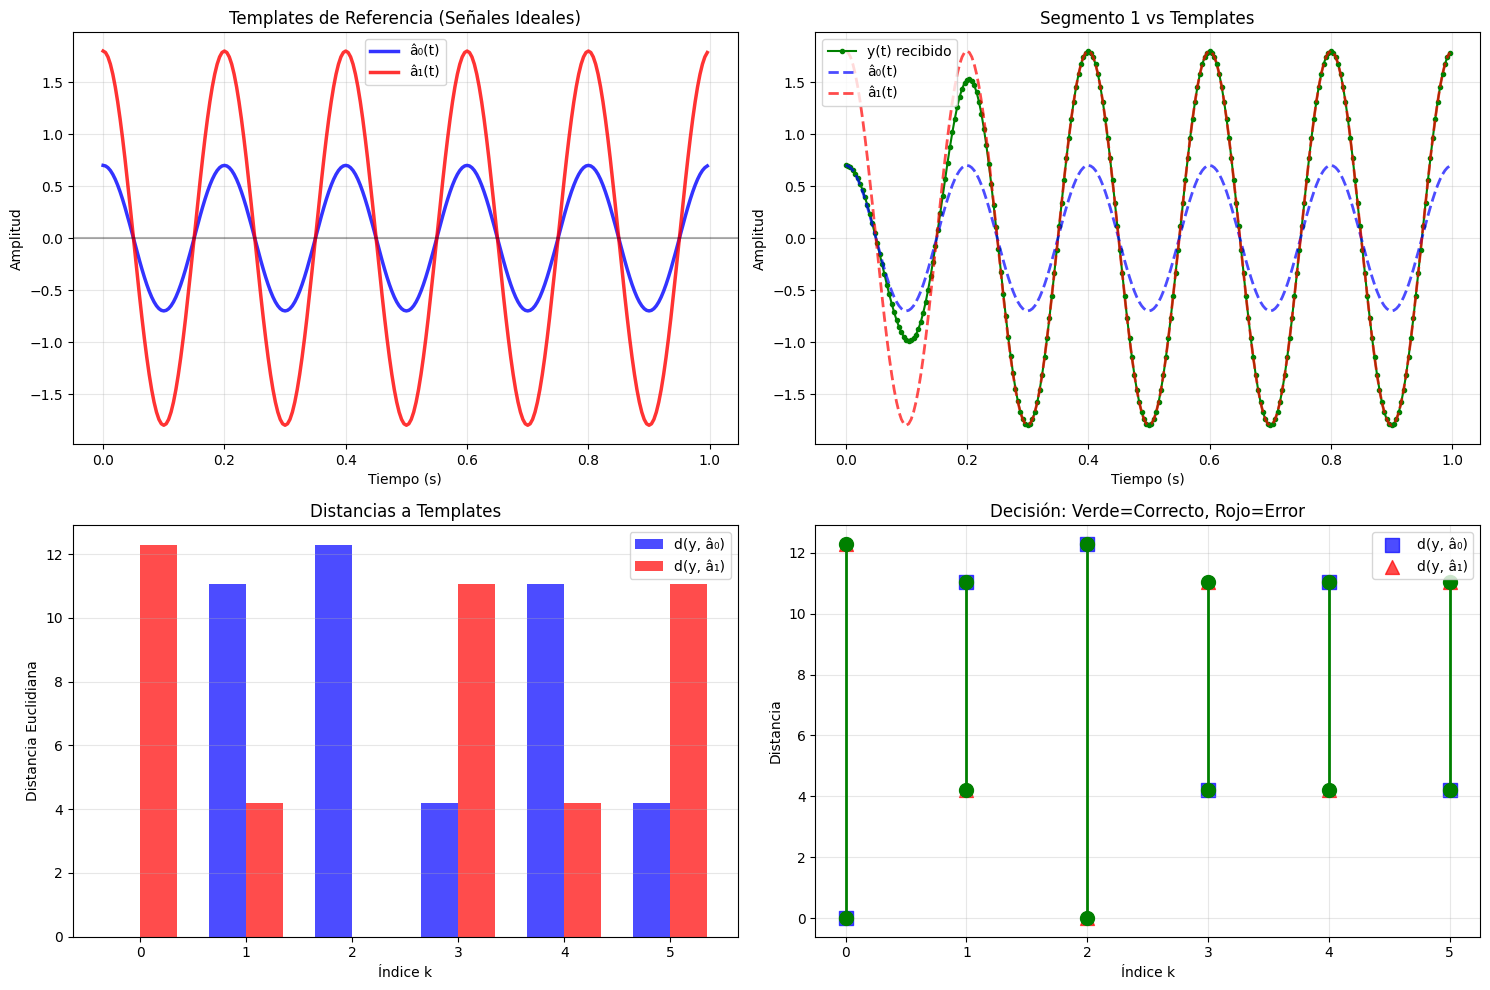

Interpretación:
  Se elige el símbolo cuyo template tiene MENOR distancia al segmento recibido


In [10]:
# ===============================================================
# CELDA 6: DISTANCIA EUCLIDIANA - d(y, âᵢ)
# ===============================================================
print("="*70)
print("CELDA 6: CÁLCULO DE DISTANCIA EUCLIDIANA")
print("="*70)

# Crear templates (señales de referencia) para a₀ y a₁
# Estos son los patrones "ideales" sin ruido
t_template = np.arange(0, Ts, delta_t)
samples_template = len(t_template)

# Templates ideales
a0_template = a0 * np.cos(2 * np.pi * f_carrier * t_template)
a1_template = a1 * np.cos(2 * np.pi * f_carrier * t_template)

a0_template_torch = torch.from_numpy(a0_template).float()
a1_template_torch = torch.from_numpy(a1_template).float()

print(f"Template â₀: {len(a0_template_torch)} muestras")
print(f"Template â₁: {len(a1_template_torch)} muestras\n")

# Calcular distancia euclidiana de cada segmento a los templates
# d(y, â) = √(Σ(y - â)²)  o  d² = Σ(y - â)²

distances_to_a0 = []
distances_to_a1 = []

for k, segment in enumerate(segments_list):
    # Asegurar que tengan la misma longitud
    min_len = min(len(segment), len(a0_template_torch))
    seg_trimmed = segment[:min_len]

    # Distancia euclidiana al cuadrado
    dist_sq_a0 = torch.sum((seg_trimmed - a0_template_torch[:min_len]) ** 2)
    dist_sq_a1 = torch.sum((seg_trimmed - a1_template_torch[:min_len]) ** 2)

    distances_to_a0.append(torch.sqrt(dist_sq_a0))
    distances_to_a1.append(torch.sqrt(dist_sq_a1))

    print(f"Segmento {k}: d(y,â₀)={torch.sqrt(dist_sq_a0).item():.4f}, "
          f"d(y,â₁)={torch.sqrt(dist_sq_a1).item():.4f} → símbolo: a{symbols[k].item():.0f}")

distances_to_a0 = torch.stack(distances_to_a0)
distances_to_a1 = torch.stack(distances_to_a1)

print("\n✓ Distancias euclidianas calculadas\n")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Templates de referencia
axes[0, 0].plot(t_template, a0_template, linewidth=2.5,
                label='â₀(t)', color='blue', alpha=0.8)
axes[0, 0].plot(t_template, a1_template, linewidth=2.5,
                label='â₁(t)', color='red', alpha=0.8)
axes[0, 0].axhline(0, color='black', linestyle='-', alpha=0.3)
axes[0, 0].set_xlabel('Tiempo (s)')
axes[0, 0].set_ylabel('Amplitud')
axes[0, 0].set_title('Templates de Referencia (Señales Ideales)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Ejemplo - segmento vs templates
k_ex = 1
axes[0, 1].plot(t_template[:len(segments_list[k_ex])], segments_list[k_ex].numpy(),
                'o-', linewidth=1.5, markersize=3, label='y(t) recibido', color='green')
axes[0, 1].plot(t_template, a0_template, '--', linewidth=2, label='â₀(t)', color='blue', alpha=0.7)
axes[0, 1].plot(t_template, a1_template, '--', linewidth=2, label='â₁(t)', color='red', alpha=0.7)
axes[0, 1].set_xlabel('Tiempo (s)')
axes[0, 1].set_ylabel('Amplitud')
axes[0, 1].set_title(f'Segmento {k_ex} vs Templates')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Distancias comparadas
x_pos = np.arange(num_symbols)
width = 0.35

axes[1, 0].bar(x_pos - width/2, distances_to_a0.numpy(), width,
               label='d(y, â₀)', color='blue', alpha=0.7)
axes[1, 0].bar(x_pos + width/2, distances_to_a1.numpy(), width,
               label='d(y, â₁)', color='red', alpha=0.7)
axes[1, 0].set_xlabel('Índice k')
axes[1, 0].set_ylabel('Distancia Euclidiana')
axes[1, 0].set_title('Distancias a Templates')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Panel 4: Decisión basada en distancia mínima
decisions_dist = (distances_to_a1 < distances_to_a0).float()
colors_decision = ['green' if decisions_dist[i] == symbols[i] else 'red'
                   for i in range(num_symbols)]

for i in range(num_symbols):
    axes[1, 1].plot([i, i], [distances_to_a0[i].item(), distances_to_a1[i].item()],
                    'o-', markersize=10, linewidth=2, color=colors_decision[i])

axes[1, 1].scatter(x_pos, distances_to_a0.numpy(), s=100,
                   marker='s', color='blue', alpha=0.7, label='d(y, â₀)')
axes[1, 1].scatter(x_pos, distances_to_a1.numpy(), s=100,
                   marker='^', color='red', alpha=0.7, label='d(y, â₁)')
axes[1, 1].set_xlabel('Índice k')
axes[1, 1].set_ylabel('Distancia')
axes[1, 1].set_title('Decisión: Verde=Correcto, Rojo=Error')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretación:")
print("  Se elige el símbolo cuyo template tiene MENOR distancia al segmento recibido")

CELDA 7: DECISIÓN POR UMBRAL Y COMPARACIÓN
Umbral de decisión: γ = 0.0

MÉTODO 1: Decisión basada en Feature ŝₖ
Regla: si ŝₖ > 0.0 → decidir a₁, sino → decidir a₀
Símbolos enviados:  [0. 1. 1. 0. 1. 0.]
Decisiones (feat):  [1. 0. 0. 1. 0. 1.]
Errores:            [1. 1. 1. 1. 1. 1.]
Tasa de error:      100.00%

MÉTODO 2: Decisión basada en Distancia Euclidiana Mínima
Regla: elegir âᵢ que minimice d(y, âᵢ)
Símbolos enviados:  [0. 1. 1. 0. 1. 0.]
Decisiones (dist):  [0. 1. 1. 0. 1. 0.]
Errores:            [0. 0. 0. 0. 0. 0.]
Tasa de error:      0.00%

✓ Decisiones calculadas



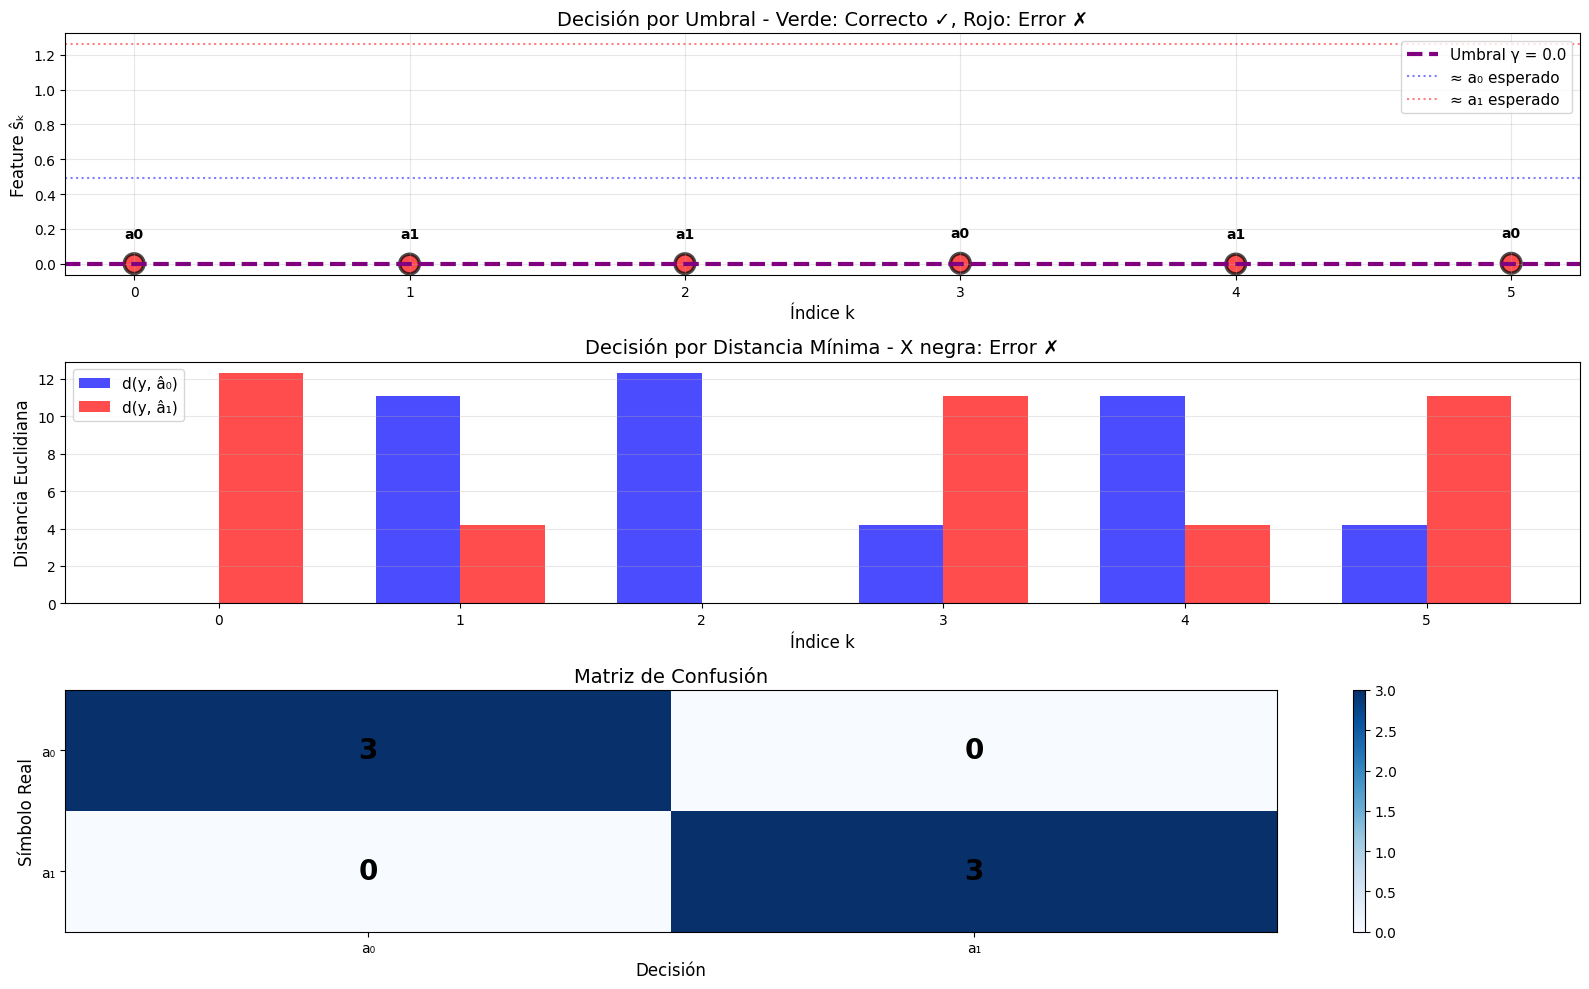

RESUMEN
Error por feature:    100.00%
Error por distancia:  0.00%


In [11]:
# ===============================================================
# CELDA 7: DECISIÓN POR UMBRAL - ŝₖ ≷ γ
# ===============================================================
print("="*70)
print("CELDA 7: DECISIÓN POR UMBRAL Y COMPARACIÓN")
print("="*70)

# Umbral de decisión (punto medio entre características esperadas de a₀ y a₁)
# Para señales moduladas con amplitudes diferentes, el umbral está cerca de 0
threshold_gamma = 0.0

print(f"Umbral de decisión: γ = {threshold_gamma}\n")

# MÉTODO 1: Decisión basada en feature (media del segmento)
print("MÉTODO 1: Decisión basada en Feature ŝₖ")
decisions_feature = (s_hat > threshold_gamma).float()
errors_feature = (decisions_feature != symbols).float()
error_rate_feature = torch.mean(errors_feature).item()

print(f"Regla: si ŝₖ > {threshold_gamma} → decidir a₁, sino → decidir a₀")
print(f"Símbolos enviados:  {symbols.numpy()}")
print(f"Decisiones (feat):  {decisions_feature.numpy()}")
print(f"Errores:            {errors_feature.numpy()}")
print(f"Tasa de error:      {error_rate_feature*100:.2f}%\n")

# MÉTODO 2: Decisión basada en distancia euclidiana mínima
print("MÉTODO 2: Decisión basada en Distancia Euclidiana Mínima")
decisions_distance = (distances_to_a1 < distances_to_a0).float()
errors_distance = (decisions_distance != symbols).float()
error_rate_distance = torch.mean(errors_distance).item()

print(f"Regla: elegir âᵢ que minimice d(y, âᵢ)")
print(f"Símbolos enviados:  {symbols.numpy()}")
print(f"Decisiones (dist):  {decisions_distance.numpy()}")
print(f"Errores:            {errors_distance.numpy()}")
print(f"Tasa de error:      {error_rate_distance*100:.2f}%\n")

print("✓ Decisiones calculadas\n")

# Visualización completa
fig = plt.figure(figsize=(16, 10))

# Panel 1: Decisión por feature con umbral
ax1 = plt.subplot(3, 1, 1)
colors_feat = ['green' if e == 0 else 'red' for e in errors_feature]
ax1.scatter(range(num_symbols), s_hat.numpy(),
            c=colors_feat, s=200, alpha=0.7, edgecolors='black', linewidths=2.5)
ax1.axhline(threshold_gamma, color='purple', linestyle='--',
            linewidth=3, label=f'Umbral γ = {threshold_gamma}')
ax1.axhline(a0*0.7, color='blue', linestyle=':', alpha=0.5, label='≈ a₀ esperado')
ax1.axhline(a1*0.7, color='red', linestyle=':', alpha=0.5, label='≈ a₁ esperado')

for i in range(num_symbols):
    symbol_text = f"a{symbols[i].item():.0f}"
    ax1.text(i, s_hat[i].item() + 0.15, symbol_text,
             ha='center', fontsize=10, fontweight='bold')

ax1.set_xlabel('Índice k', fontsize=12)
ax1.set_ylabel('Feature ŝₖ', fontsize=12)
ax1.set_title('Decisión por Umbral - Verde: Correcto ✓, Rojo: Error ✗', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(num_symbols))

# Panel 2: Comparación de distancias
ax2 = plt.subplot(3, 1, 2)
x_pos = np.arange(num_symbols)
width = 0.35

ax2.bar(x_pos - width/2, distances_to_a0.numpy(), width,
        label='d(y, â₀)', color='blue', alpha=0.7)
ax2.bar(x_pos + width/2, distances_to_a1.numpy(), width,
        label='d(y, â₁)', color='red', alpha=0.7)

# Marcar errores con X
for i in range(num_symbols):
    if errors_distance[i] == 1:
        max_dist = max(distances_to_a0[i], distances_to_a1[i])
        ax2.plot(i, max_dist * 1.1, 'kx', markersize=20, markeredgewidth=4)

ax2.set_xlabel('Índice k', fontsize=12)
ax2.set_ylabel('Distancia Euclidiana', fontsize=12)
ax2.set_title('Decisión por Distancia Mínima - X negra: Error ✗', fontsize=14)
ax2.set_xticks(x_pos)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Matriz de confusión
ax3 = plt.subplot(3, 1, 3)

# Usar el método de distancia (generalmente mejor)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(symbols.numpy(), decisions_distance.numpy())

im = ax3.imshow(cm, cmap='Blues', aspect='auto')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['a₀', 'a₁'])
ax3.set_yticklabels(['a₀', 'a₁'])
ax3.set_xlabel('Decisión', fontsize=12)
ax3.set_ylabel('Símbolo Real', fontsize=12)
ax3.set_title('Matriz de Confusión', fontsize=14)

# Agregar valores en las celdas
for i in range(2):
    for j in range(2):
        text = ax3.text(j, i, int(cm[i, j]),
                       ha="center", va="center", color="black", fontsize=20, fontweight='bold')

plt.colorbar(im, ax=ax3)
plt.tight_layout()
plt.show()

print("="*70)
print("RESUMEN")
print("="*70)
print(f"Error por feature:    {error_rate_feature*100:.2f}%")
print(f"Error por distancia:  {error_rate_distance*100:.2f}%")
print("="*70)

CELDA 8: PRODUCTO INTERNO Y VISUALIZACIÓN FINAL
Segmento 0: ⟨y,â₀⟩=  +61.25, ⟨y,â₁⟩= +157.50 → a0
Segmento 1: ⟨y,â₀⟩= +142.68, ⟨y,â₁⟩= +366.89 → a1
Segmento 2: ⟨y,â₀⟩= +157.50, ⟨y,â₁⟩= +405.00 → a1
Segmento 3: ⟨y,â₀⟩=  +76.07, ⟨y,â₁⟩= +195.61 → a0
Segmento 4: ⟨y,â₀⟩= +142.68, ⟨y,â₁⟩= +366.89 → a1
Segmento 5: ⟨y,â₀⟩=  +76.07, ⟨y,â₁⟩= +195.61 → a0

Tasa de error (producto interno): 50.00%
✓ Productos internos calculados



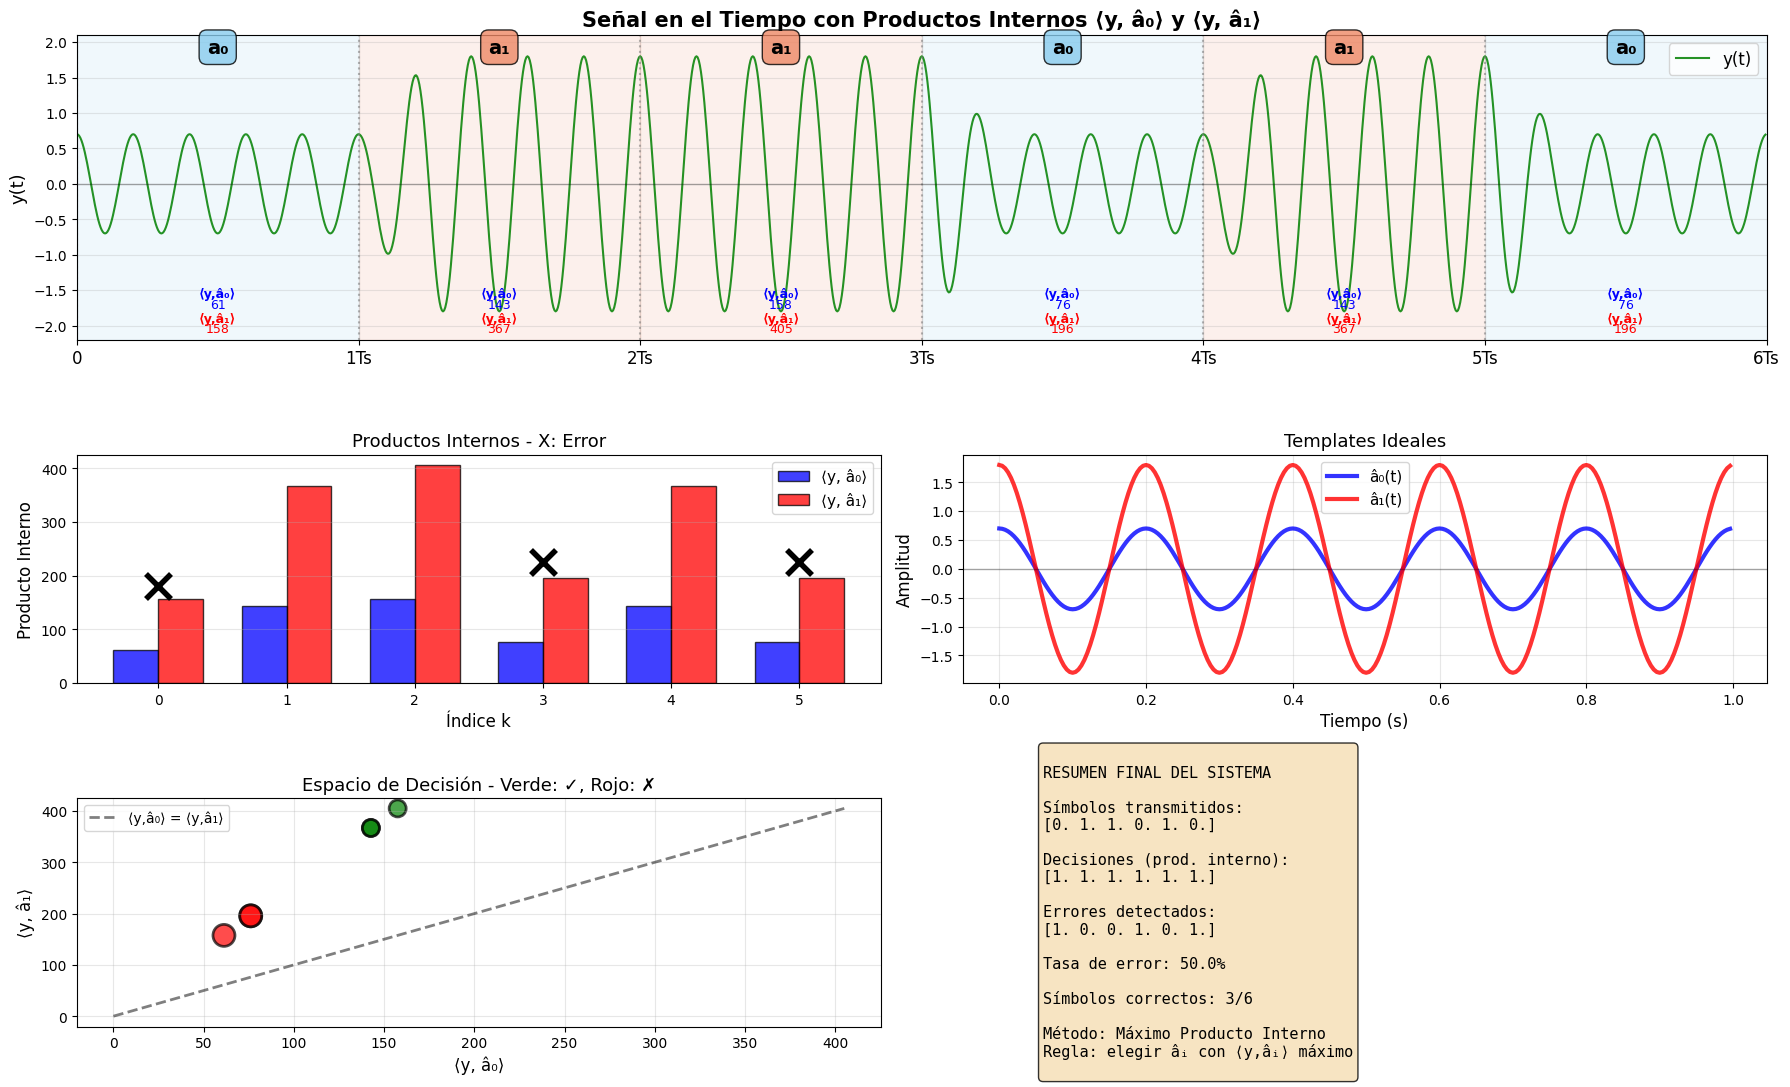


PROCESO COMPLETO FINALIZADO
Este es el flujo que el profesor explicó para preparar datos
antes de entrenar redes neuronales:
  1. Señal continua → 2. Discretización (Δt)
  3. Segmentación (Ts) → 4. Feature extraction
  5. Cálculo de σ²yk → 6. Distancia euclidiana
  7. Decisión por umbral → 8. Producto interno


In [12]:
# ===============================================================
# CELDA 8: VISUALIZACIÓN FINAL - PRODUCTO INTERNO ⟨y, âᵢ⟩
# ===============================================================
print("="*70)
print("CELDA 8: PRODUCTO INTERNO Y VISUALIZACIÓN FINAL")
print("="*70)

# Calcular productos internos ⟨y, âᵢ⟩ = Σ y(t) · âᵢ(t)
# El producto interno mide la "similitud" o "correlación" entre señales

inner_products_a0 = []
inner_products_a1 = []

for k, segment in enumerate(segments_list):
    # Asegurar misma longitud
    min_len = min(len(segment), len(a0_template_torch))
    seg_trimmed = segment[:min_len]

    # ⟨y, â₀⟩
    inner_a0 = torch.sum(seg_trimmed * a0_template_torch[:min_len])
    inner_products_a0.append(inner_a0)

    # ⟨y, â₁⟩
    inner_a1 = torch.sum(seg_trimmed * a1_template_torch[:min_len])
    inner_products_a1.append(inner_a1)

    print(f"Segmento {k}: ⟨y,â₀⟩={inner_a0.item():+8.2f}, "
          f"⟨y,â₁⟩={inner_a1.item():+8.2f} → a{symbols[k].item():.0f}")

inner_products_a0 = torch.stack(inner_products_a0)
inner_products_a1 = torch.stack(inner_products_a1)

# Decisión: elegir el símbolo con MAYOR producto interno
decisions_inner = (inner_products_a1 > inner_products_a0).float()
errors_inner = (decisions_inner != symbols).float()
error_rate_inner = torch.mean(errors_inner).item()

print(f"\nTasa de error (producto interno): {error_rate_inner*100:.2f}%")
print("✓ Productos internos calculados\n")

# ========== VISUALIZACIÓN FINAL COMO EL PROFESOR ==========
fig = plt.figure(figsize=(18, 11))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1.5, 1.5])

# PANEL PRINCIPAL: Señal en el tiempo con anotaciones
ax_main = fig.add_subplot(gs[0, :])
ax_main.plot(t, signal_noisy, linewidth=1.5, color='green', alpha=0.85, label='y(t)')

for k in range(num_symbols):
    start_t = k * Ts
    end_t = (k + 1) * Ts
    mid_t = (start_t + end_t) / 2

    # Sombrear región según símbolo
    color = '#88ccee' if symbols[k] == 0 else '#ee8866'
    ax_main.axvspan(start_t, end_t, alpha=0.12, color=color)
    ax_main.axvline(start_t, color='gray', linestyle=':', alpha=0.6, linewidth=1.5)

    # Etiqueta del símbolo ARRIBA
    label_sym = 'a₀' if symbols[k] == 0 else 'a₁'
    ax_main.text(mid_t, 1.85, label_sym, ha='center', fontsize=14, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.8))

    # Productos internos ABAJO (como el profesor)
    y_pos_base = -1.6
    ax_main.text(mid_t, y_pos_base, f'⟨y,â₀⟩', ha='center', fontsize=9,
                color='blue', fontweight='bold')
    ax_main.text(mid_t, y_pos_base-0.15, f'{inner_products_a0[k].item():.0f}',
                ha='center', fontsize=9, color='blue')

    ax_main.text(mid_t, y_pos_base-0.35, f'⟨y,â₁⟩', ha='center', fontsize=9,
                color='red', fontweight='bold')
    ax_main.text(mid_t, y_pos_base-0.5, f'{inner_products_a1[k].item():.0f}',
                ha='center', fontsize=9, color='red')

# Marcas en eje X: 0, Ts, 2Ts, 3Ts...
x_ticks_main = [k * Ts for k in range(num_symbols + 1)]
x_labels_main = ['0'] + [f'{k}Ts' for k in range(1, num_symbols + 1)]
ax_main.set_xticks(x_ticks_main)
ax_main.set_xticklabels(x_labels_main, fontsize=12)

ax_main.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax_main.set_ylabel('y(t)', fontsize=13)
ax_main.set_title('Señal en el Tiempo con Productos Internos ⟨y, â₀⟩ y ⟨y, â₁⟩',
                  fontsize=15, fontweight='bold')
ax_main.legend(fontsize=12, loc='upper right')
ax_main.grid(True, alpha=0.3)
ax_main.set_xlim(0, t_total)
ax_main.set_ylim(-2.2, 2.1)

# PANEL 2: Comparación de productos internos (barras)
ax2 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(num_symbols)
width = 0.35

ax2.bar(x_pos - width/2, inner_products_a0.numpy(), width,
        label='⟨y, â₀⟩', color='blue', alpha=0.75, edgecolor='black', linewidth=1)
ax2.bar(x_pos + width/2, inner_products_a1.numpy(), width,
        label='⟨y, â₁⟩', color='red', alpha=0.75, edgecolor='black', linewidth=1)

# Marcar errores
for i in range(num_symbols):
    if errors_inner[i] == 1:
        max_val = max(inner_products_a0[i], inner_products_a1[i])
        ax2.plot(i, max_val * 1.15, 'kx', markersize=18, markeredgewidth=4)

ax2.set_xlabel('Índice k', fontsize=12)
ax2.set_ylabel('Producto Interno', fontsize=12)
ax2.set_title('Productos Internos - X: Error', fontsize=13)
ax2.set_xticks(x_pos)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# PANEL 3: Templates de referencia
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(t_template, a0_template, linewidth=3, label='â₀(t)', color='blue', alpha=0.8)
ax3.plot(t_template, a1_template, linewidth=3, label='â₁(t)', color='red', alpha=0.8)
ax3.axhline(0, color='black', linestyle='-', alpha=0.3, linewidth=1)
ax3.set_xlabel('Tiempo (s)', fontsize=12)
ax3.set_ylabel('Amplitud', fontsize=12)
ax3.set_title('Templates Ideales', fontsize=13)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# PANEL 4: Decisiones (scatter)
ax4 = fig.add_subplot(gs[2, 0])
colors_decision = ['green' if e == 0 else 'red' for e in errors_inner]
sizes = [250 if e == 1 else 150 for e in errors_inner]

ax4.scatter(inner_products_a0.numpy(), inner_products_a1.numpy(),
           c=colors_decision, s=sizes, alpha=0.7, edgecolors='black', linewidths=2)
ax4.plot([0, max(inner_products_a0.max(), inner_products_a1.max())],
         [0, max(inner_products_a0.max(), inner_products_a1.max())],
         'k--', linewidth=2, alpha=0.5, label='⟨y,â₀⟩ = ⟨y,â₁⟩')
ax4.set_xlabel('⟨y, â₀⟩', fontsize=12)
ax4.set_ylabel('⟨y, â₁⟩', fontsize=12)
ax4.set_title('Espacio de Decisión - Verde: ✓, Rojo: ✗', fontsize=13)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# PANEL 5: Resumen numérico
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('off')

summary_text = f"""
RESUMEN FINAL DEL SISTEMA

Símbolos transmitidos:
{symbols.numpy()}

Decisiones (prod. interno):
{decisions_inner.numpy()}

Errores detectados:
{errors_inner.numpy()}

Tasa de error: {error_rate_inner*100:.1f}%

Símbolos correctos: {int((1-error_rate_inner)*num_symbols)}/{num_symbols}

Método: Máximo Producto Interno
Regla: elegir âᵢ con ⟨y,âᵢ⟩ máximo
"""

ax5.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PROCESO COMPLETO FINALIZADO")
print("="*70)
print("Este es el flujo que el profesor explicó para preparar datos")
print("antes de entrenar redes neuronales:")
print("  1. Señal continua → 2. Discretización (Δt)")
print("  3. Segmentación (Ts) → 4. Feature extraction")
print("  5. Cálculo de σ²yk → 6. Distancia euclidiana")
print("  7. Decisión por umbral → 8. Producto interno")
print("="*70)